# **Assignment-9: K-Means Clustering**

AIM: Apply K-Means clustering on a dataset, understand cluster formation, and visualize results.


Import Required libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
print('Libraries imported')

Libraries imported


In [3]:
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data'
columns = ['sepal_length','sepal_width','petal_length','petal_width','class']
df = pd.read_csv(url, names=columns)
df.head()

,sepal_length,sepal_width,petal_length,petal_width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


Dataset Overview

In [4]:
print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
df.describe()

Shape: (150, 5)

Columns: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'class']


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


Select Features for Clustering (Two Features for Visualization)

In [6]:
X = df[['sepal_length', 'sepal_width']]
X.head()

,sepal_length,sepal_width
0,5.1,3.5
1,4.9,3.0
2,4.7,3.2
3,4.6,3.1
4,5.0,3.6


Visualize Raw Data (Scatter Plot)

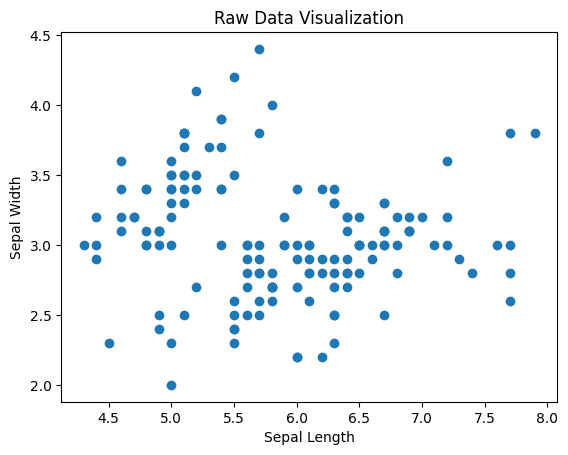

In [7]:
plt.scatter(X.iloc[:,0], X.iloc[:,1])
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.title('Raw Data Visualization')
plt.show()

Apply K-Means Algorithm (K = 3)

In [8]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X)
print('Model trained')

Model trained


Assign Cluster Labels to Dataset

In [10]:
X_clustered = X.copy()
X_clustered['Cluster'] = kmeans.labels_
X_clustered.head()

,sepal_length,sepal_width,Cluster
0,5.1,3.5,2
1,4.9,3.0,2
2,4.7,3.2,2
3,4.6,3.1,2
4,5.0,3.6,2


Elbow Method to Find Best K

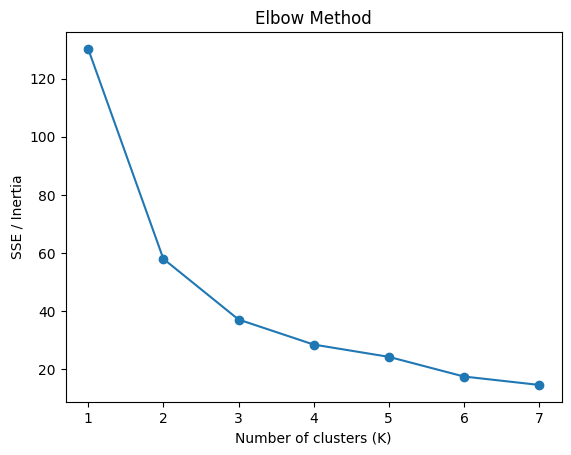

In [9]:
sse = []
K = range(1, 8)
for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X)
    sse.append(km.inertia_)

plt.plot(K, sse, marker='o')
plt.xlabel('Number of clusters (K)')
plt.ylabel('SSE / Inertia')
plt.title('Elbow Method')
plt.show()

Visualize Final Clusters with Centroids

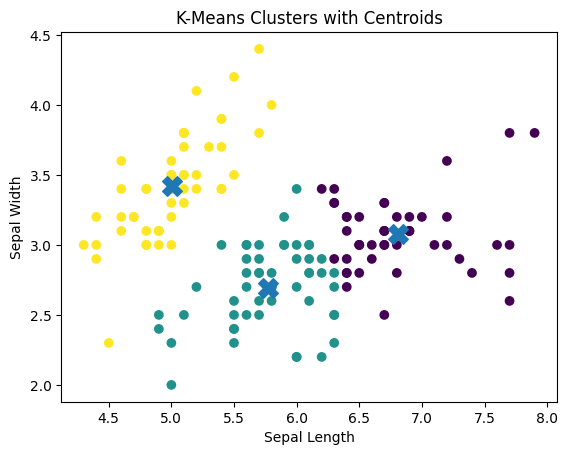

In [11]:
plt.scatter(X.iloc[:,0], X.iloc[:,1], c=kmeans.labels_)
centers = kmeans.cluster_centers_
plt.scatter(centers[:,0], centers[:,1], marker='X', s=200)
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.title('K-Means Clusters with Centroids')
plt.show()

Interpret Clustering Results

Observations from K-Means Clustering:

1.  **Number of Clusters:** The K-Means algorithm was set to find 3 clusters (`n_clusters=3`), which is a common choice for the Iris dataset given its three species. The elbow method plot also suggests that after K=3, the decrease in SSE becomes less significant.

2.  **How Points are Grouped:**
    *   **Cluster 0 (e.g., center: sepal_length ~6.8, sepal_width ~3.1):** This cluster appears to group flowers with generally *longer sepal lengths* and *average sepal widths*.
    *   **Cluster 1 (e.g., center: sepal_length ~5.8, sepal_width ~2.7):** This cluster contains flowers with *medium sepal lengths* and *narrower sepal widths*.
    *   **Cluster 2 (e.g., center: sepal_length ~5.0, sepal_width ~3.4):** This cluster includes flowers characterized by *shorter sepal lengths* and *wider sepal widths*.

3.  **Differences Between Clusters:**
    *   **Cluster 2** is distinctly separated from the other two, primarily by its *shorter sepal length* and *wider sepal width*. Visually, this corresponds to the group on the bottom-left of the scatter plot.
    *   **Clusters 0 and 1** show some overlap but are generally distinguished by their sepal width and length. Cluster 0 has longer sepal lengths and slightly wider sepal widths compared to Cluster 1, which has medium sepal lengths and narrower sepal widths.

These observations align with the visual representation of the clusters and centroids on the scatter plot. The clustering effectively groups the data points into distinct categories based on their sepal dimensions.

Conclusion:

K-Means clustering partitions data into `k` groups by iteratively assigning points to the nearest centroid and updating cluster centers. It’s widely used for tasks like customer segmentation, anomaly detection, and image/document analysis. In the Iris dataset experiment, it effectively formed 3 clusters that aligned with the species, showing clear groupings based on sepal dimensions.